# Temperature analysis (0-7 m)

Same workflow as `Salinity_analysis.ipynb`, but for potential temperature (`votemper`).

Outputs:
- `temp_meso_0_7m.zarr` : daily depth-averaged (0-7 m) temperature (mesoscale)
- `temp_m_0_7m.zarr` : monthly-mean depth-averaged (0-7 m) temperature

In [1]:
import xarray as xr
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches
from tqdm import tqdm

In [2]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=3, memory_limit=15e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 55.88 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43885,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45383,Total threads: 3
Dashboard: http://127.0.0.1:38887/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:35609,


In [3]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [5]:
def seasonality(data):
    season = data.groupby('time.month').mean(dim='time')
    return season

def anomaly(data):
    """Compute anomalies by removing the seasonal cycle (monthly climatology)."""
    clim = seasonality(data)
    anom = data.groupby('time.month') - clim
    return anom

## Load temperature (top 7 levels ~ 0-7 m)

In [6]:
temp = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/T_*.nc',
                         chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
                         ).isel(deptht=slice(0, 7))
temp = temp.rename({'votemper':'temp','time_counter':'time','deptht':'depth'}).assign_coords({
    'lat': temp.nav_lat.isel(x=0).load(),
    'lon': temp.nav_lon.isel(y=0).load()})\
    .drop_vars({'nav_lon','nav_lat'})\
        .swap_dims({'x':'lon','y':'lat'}).drop_vars({'x','y'})
temp

<xarray.Dataset> Size: 140GB
Dimensions:  (time: 7973, depth: 7, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
  * depth    (depth) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    temp     (time, depth, lat, lon) float32 140GB dask.array<chunksize=(31, 7, 250, 600), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 00:15:42 2025: cdo setmissval,nan T_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [7]:
dz = np.diff(temp['depth'].values, prepend=0)
dz = xr.DataArray(dz, dims='depth', coords={'depth': temp['depth']})
dz

<xarray.DataArray (depth: 7)> Size: 56B
array([0.49402538, 1.04735002, 1.10429311, 1.17382622, 1.25872898,
       1.36239052, 1.48894596])
Coordinates:
  * depth    (depth) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93

## Daily depth-averaged temperature (mesoscale) -> `temp_meso_0_7m.zarr`

In [8]:
temp_meso = temp.temp.weighted(dz).mean('depth')
temp_meso = temp_meso.chunk({'time': 30})
temp_meso

<xarray.DataArray 'temp' (time: 7973, lat: 499, lon: 1260)> Size: 40GB
dask.array<rechunk-merge, shape=(7973, 499, 1260), dtype=float64, chunksize=(30, 250, 600), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917

In [9]:
temp_meso.drop_encoding().to_zarr('temp_meso_0_7m.zarr', mode='w')

## Monthly-mean depth-averaged temperature -> `temp_m_0_7m.zarr`

In [10]:
tempi = temp.temp.weighted(dz).mean('depth').resample(time='MS').mean()
tempi

<xarray.DataArray 'temp' (time: 264, lat: 499, lon: 1260)> Size: 1GB
dask.array<where, shape=(264, 499, 1260), dtype=float64, chunksize=(1, 250, 600), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01

In [11]:
tempi.drop_encoding().to_zarr('temp_m_0_7m.zarr', mode='w')

## Plotting the temperature

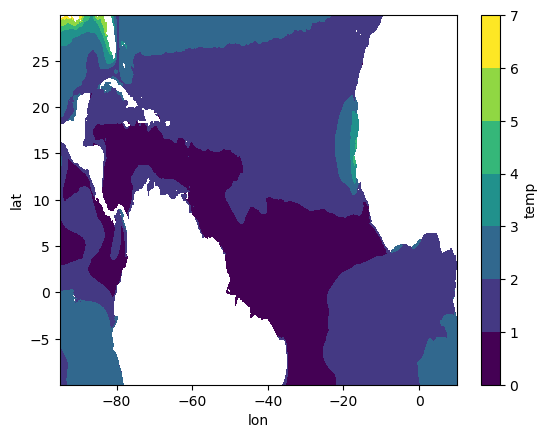

In [12]:
aa = xr.open_zarr('temp_m_0_7m.zarr').compute()
aa.std('time').temp.plot.contourf()

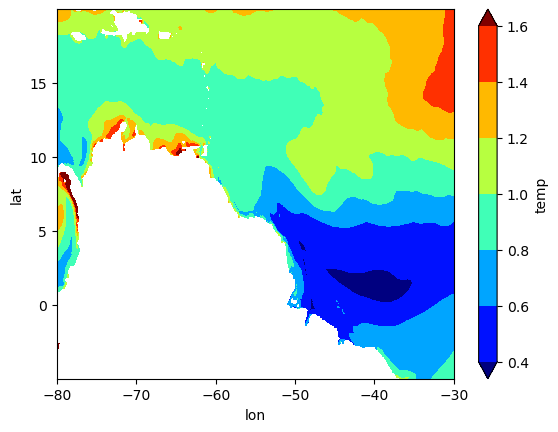

In [13]:
aa.std('time').sel(lat=slice(-5,20),lon=slice(-80,-30)).temp.plot.contourf(robust=True,cmap='jet')

### Replicating Liang et al., 2020
* ARP Area 15N-0N, 65W-49W

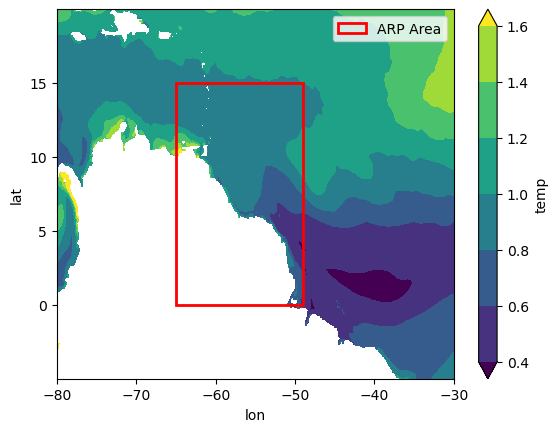

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Your plot
aa.std('time').sel(lat=slice(-5,20), lon=slice(-80,-30)).temp.plot.contourf(robust=True)

# Add the ARP box
ax = plt.gca()
rect = mpatches.Rectangle(
    xy=(-65, 0),           # bottom-left corner (lon, lat)
    width=16,              # 65W to 49W = 16 degrees
    height=15,             # 0N to 15N = 15 degrees
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    label='ARP Area'
)
ax.add_patch(rect)
ax.legend()

plt.show()

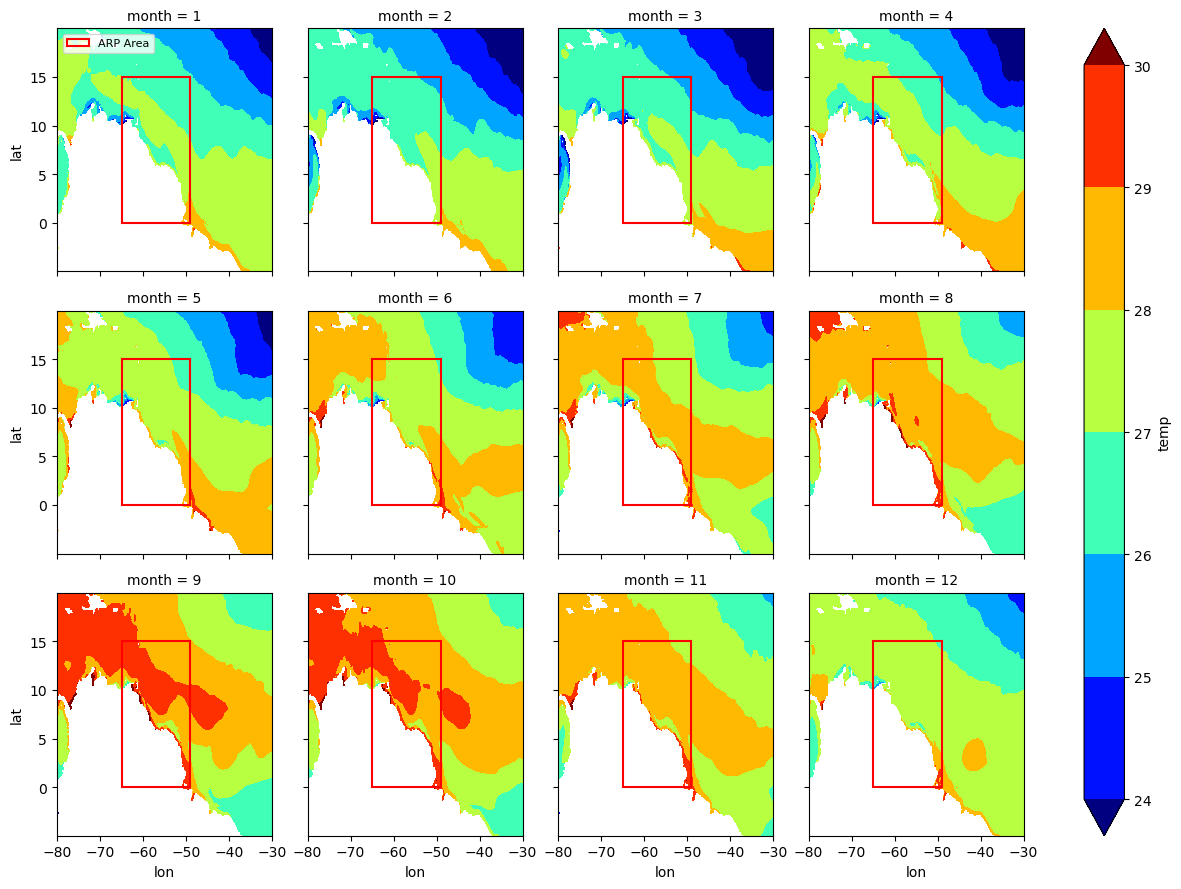

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create the facet plot
g = seasonality(aa.sel(lat=slice(-5, 20), lon=slice(-80, -30)).temp).plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4, cmap='jet', robust=True
)

# Loop over all axes and add the rectangle
for ax in g.axs.flat:
    rect = mpatches.Rectangle(
        xy=(-65, 0),
        width=16,
        height=15,
        linewidth=1.5,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

# Add legend to the first subplot (optional)
g.axs.flat[0].legend(['ARP Area'], loc='upper left', fontsize=8)

plt.show()

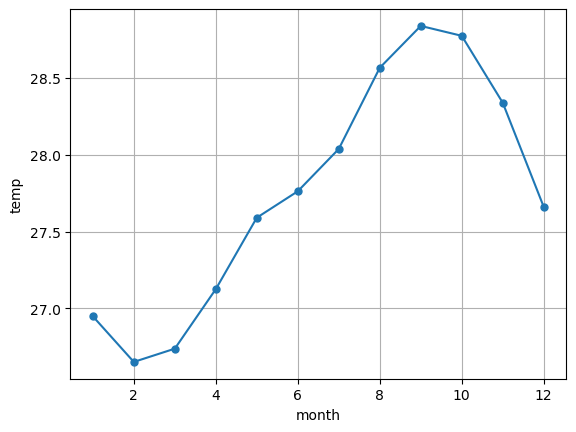

In [16]:
seasonality(aa.sel(lat=slice(0,15), lon=slice(-65,-49)).temp)\
    .mean(dim=('lon','lat')).plot(marker='.',markersize=10)
plt.grid()

### My ARP definition

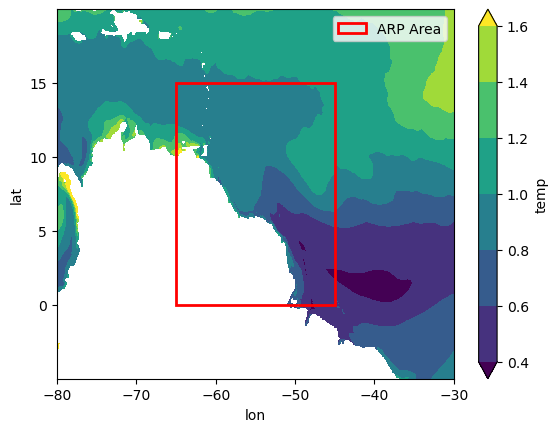

In [17]:
# Your plot
aa.std('time').sel(lat=slice(-5,20), lon=slice(-80,-30)).temp.plot.contourf(robust=True)

# Add the ARP box
ax = plt.gca()
rect = mpatches.Rectangle(
    xy=(-65, 0),           # bottom-left corner (lon, lat)
    width=20,
    height=15,
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    label='ARP Area'
)
ax.add_patch(rect)
ax.legend()

plt.show()

In [ ]:
# Create the facet plot
g = seasonality(aa.sel(lat=slice(-5,20), lon=slice(-80,-30)).temp).plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4, cmap='jet', levels=11, robust=True
)

# Loop over all axes and add the rectangle
for ax in g.axs.flat:
    rect = mpatches.Rectangle(
        xy=(-65, -2),
        width=20,
        height=20,
        linewidth=1.5,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

# Add legend to the first subplot (optional)
g.axs.flat[0].legend(['ARP Area'], loc='upper left', fontsize=8)

plt.show()

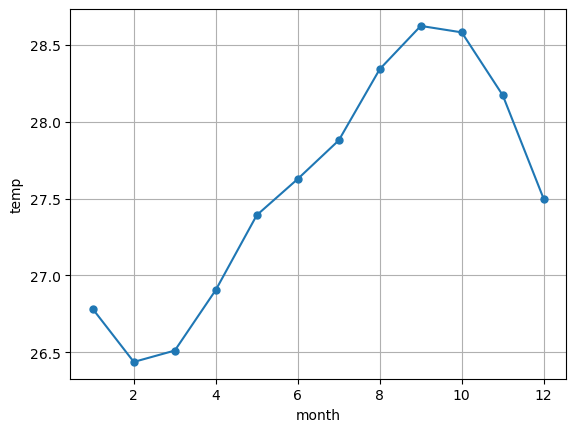

In [18]:
seasonality(aa.sel(lat=slice(0,18), lon=slice(-65,-45)).temp)\
    .mean(dim=('lon','lat')).plot(marker='.',markersize=10)
plt.grid()

#### Temperature Anomaly

In [19]:
t_anom = anomaly(aa)
t_anom = t_anom.assign_coords(year = t_anom.time.dt.year)
t_anom

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 499, lon: 1260, time: 264)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
    month    (time) int64 2kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
    year     (time) int64 2kB 1993 1993 1993 1993 1993 ... 2014 2014 2014 2014
Data variables:
    temp     (time, lat, lon) float64 1GB 0.1069 0.109 0.1116 ... nan nan nan

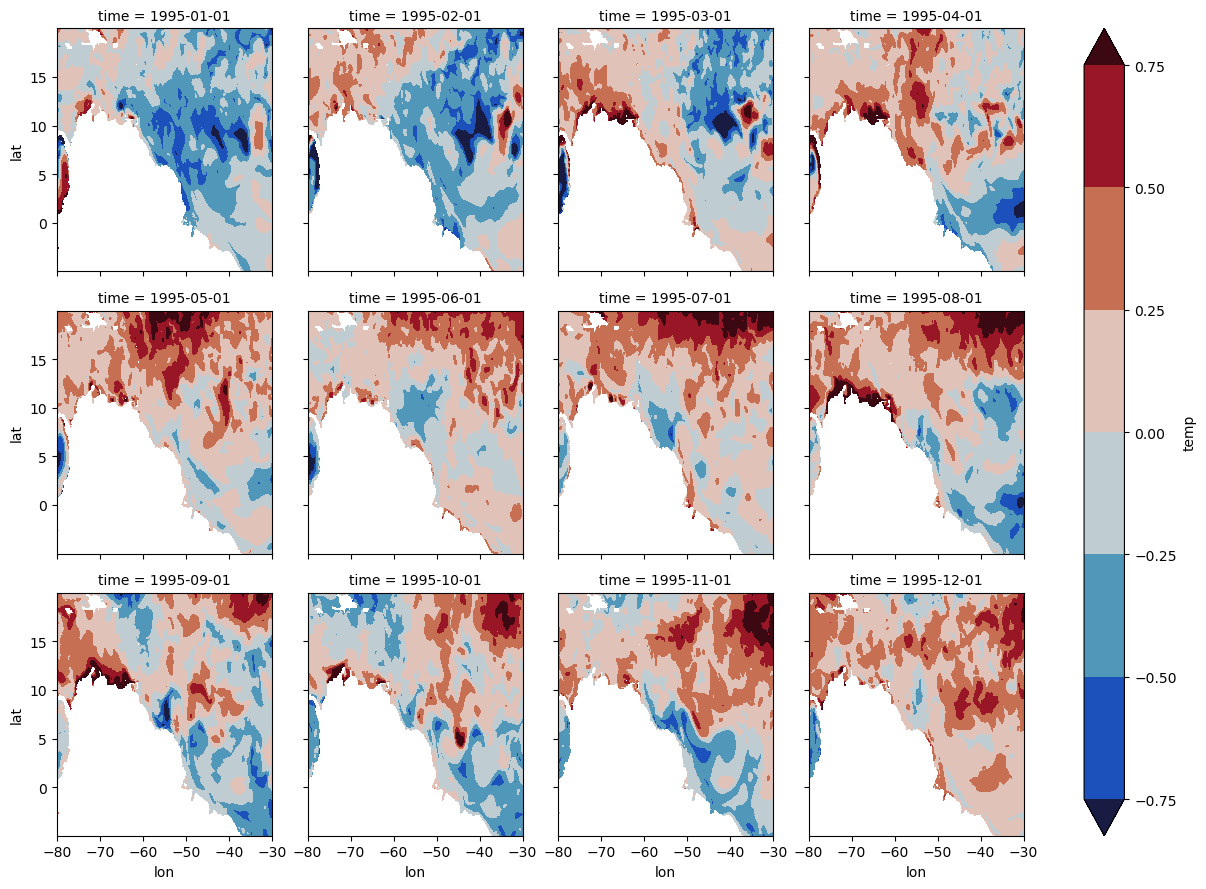

In [21]:
import cmocean as cm

t_anom.sel(time=t_anom.year == 1995).temp.sel(lat=slice(-5,20), lon=slice(-80,-30))\
    .plot.contourf(x='lon',y='lat',col='time',col_wrap=4,robust=True,cmap=cm.cm.balance)

### Mesoscale

In [22]:
temp_meso = xr.open_zarr('temp_meso_0_7m.zarr')\
    .assign_coords(year = temp_meso.time.dt.year, month=temp_meso.time.dt.month)

temp_meso

<xarray.Dataset> Size: 40GB
Dimensions:  (lat: 499, lon: 1260, time: 7973)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
    year     (time) int64 64kB 1993 1993 1993 1993 1993 ... 2014 2014 2014 2014
    month    (time) int64 64kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12 12
Data variables:
    temp     (time, lat, lon) float64 40GB dask.array<chunksize=(30, 250, 600), meta=np.ndarray>

In [23]:
temp_meso_anom = anomaly(temp_meso)
temp_meso_anom

<xarray.Dataset> Size: 40GB
Dimensions:  (lat: 499, lon: 1260, time: 7973)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
    year     (time) int64 64kB 1993 1993 1993 1993 1993 ... 2014 2014 2014 2014
    month    (time) int64 64kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12 12
Data variables:
    temp     (time, lat, lon) float64 40GB dask.array<chunksize=(1, 250, 600), meta=np.ndarray>

In [24]:
temp_April = temp_meso.sel(time=(temp_meso.year == 1995)&(temp_meso.month == 4)).compute()
temp_April = temp_April.isel(time=slice(1, None))
temp_April

<xarray.Dataset> Size: 146MB
Dimensions:  (lat: 499, lon: 1260, time: 29)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 232B 1995-04-02T12:00:00 ... 1995-04-30T12...
    year     (time) int64 232B 1995 1995 1995 1995 1995 ... 1995 1995 1995 1995
    month    (time) int64 232B 4 4 4 4 4 4 4 4 4 4 4 4 ... 4 4 4 4 4 4 4 4 4 4 4
Data variables:
    temp     (time, lat, lon) float64 146MB 26.55 26.54 26.54 ... nan nan nan

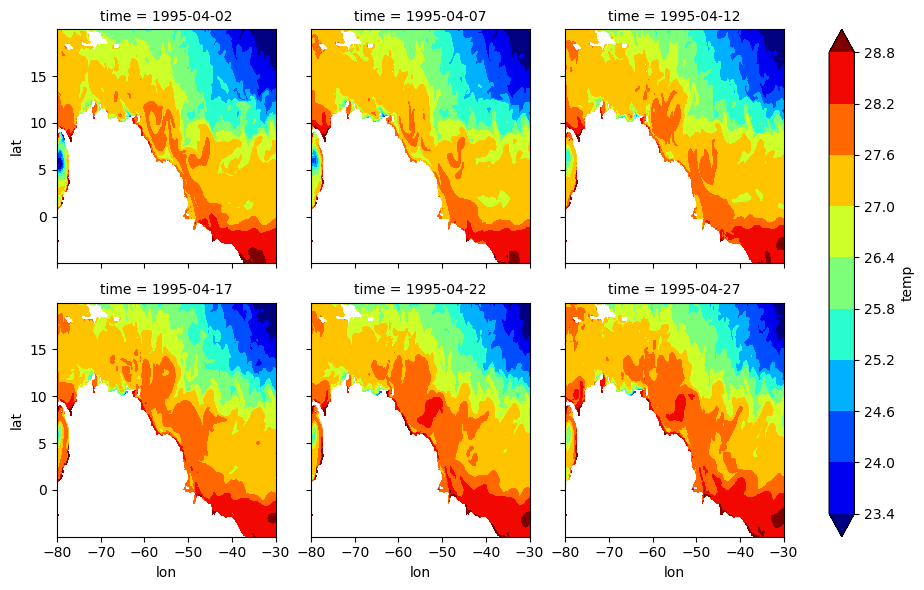

In [25]:
temp_April.resample(time='5D').mean().sel(lat=slice(-5,20), lon=slice(-80,-30)).temp\
    .plot.contourf(x='lon',y='lat',col='time',col_wrap=3,cmap='jet',levels=11,robust=True)

Text(0.5, 1.0, '1995-04-17')

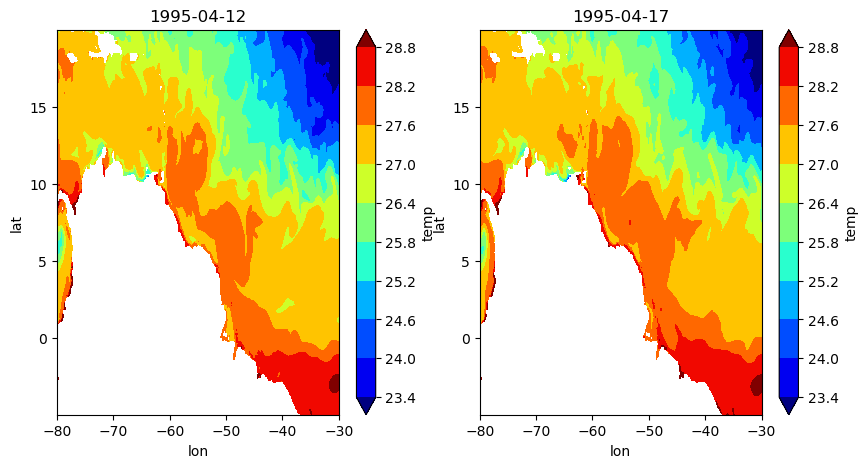

In [26]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

temp_April.sel(time=slice('1995-04-12','1995-04-22')).sel(lat=slice(-5,20), lon=slice(-80,-30))\
    .temp.mean(dim='time').plot.contourf(robust=True,cmap='jet',levels=11,ax=ax[0])

temp_April.sel(time=slice('1995-04-17','1995-04-27')).sel(lat=slice(-5,20), lon=slice(-80,-30))\
    .temp.mean(dim='time').plot.contourf(robust=True,cmap='jet',levels=11,ax=ax[1])

ax[0].set_title('1995-04-12')
ax[1].set_title('1995-04-17')

#### Now the Meso anomaly

In [27]:
temp_anom_April = temp_meso_anom.sel(time=(temp_meso_anom.year == 1995)&(temp_meso_anom.month == 4)).compute()
temp_anom_April = temp_anom_April.isel(time=slice(1, None))
temp_anom_April

<xarray.Dataset> Size: 146MB
Dimensions:  (lat: 499, lon: 1260, time: 29)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 232B 1995-04-02T12:00:00 ... 1995-04-30T12...
    year     (time) int64 232B 1995 1995 1995 1995 1995 ... 1995 1995 1995 1995
    month    (time) int64 232B 4 4 4 4 4 4 4 4 4 4 4 4 ... 4 4 4 4 4 4 4 4 4 4 4
Data variables:
    temp     (time, lat, lon) float64 146MB -0.007858 -0.009317 ... nan nan

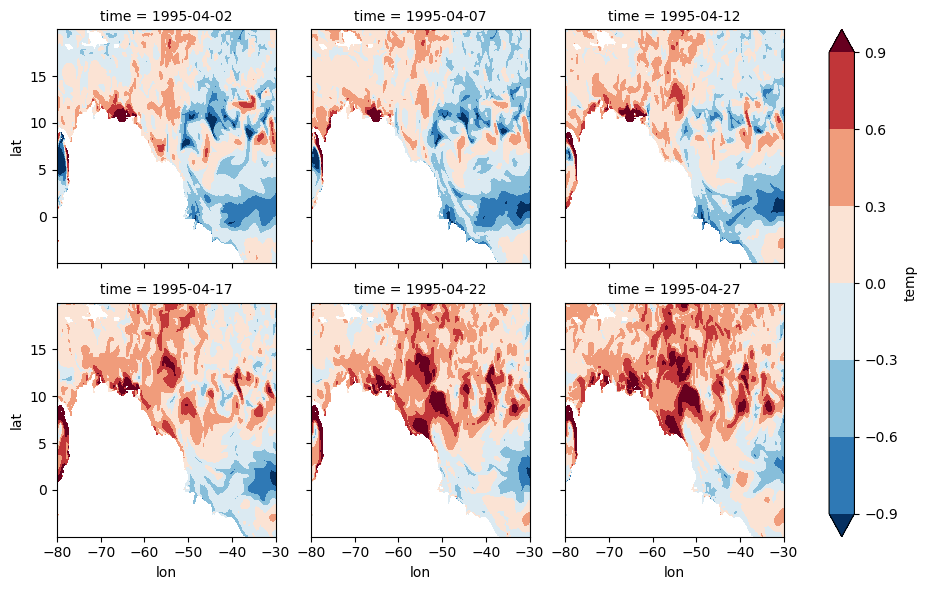

In [28]:
temp_anom_April.resample(time='5D').mean().sel(lat=slice(-5,20), lon=slice(-80,-30)).temp\
    .plot.contourf(x='lon',y='lat',col='time',col_wrap=3,cmap='RdBu_r',robust=True)

Text(0.5, 1.0, '1995-04-17')

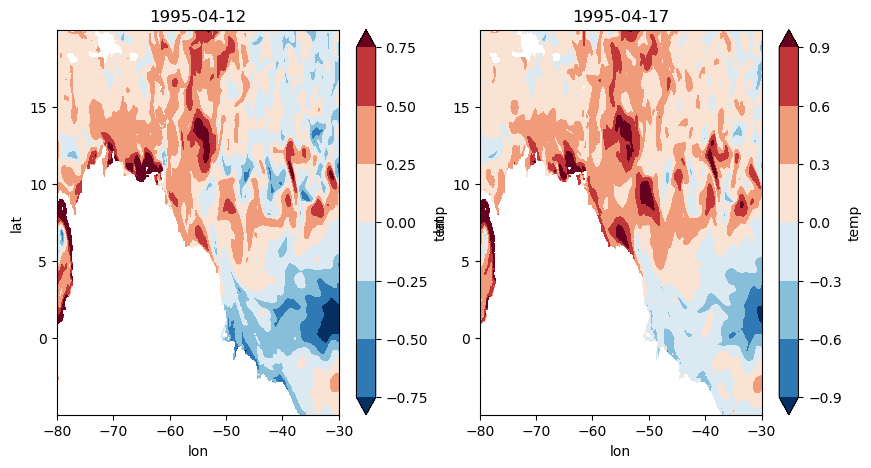

In [29]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

temp_anom_April.sel(time=slice('1995-04-12','1995-04-22')).sel(lat=slice(-5,20), lon=slice(-80,-30))\
    .temp.mean(dim='time').plot.contourf(robust=True,cmap='RdBu_r',ax=ax[0])

temp_anom_April.sel(time=slice('1995-04-17','1995-04-27')).sel(lat=slice(-5,20), lon=slice(-80,-30))\
    .temp.mean(dim='time').plot.contourf(robust=True,cmap='RdBu_r',ax=ax[1])

ax[0].set_title('1995-04-12')
ax[1].set_title('1995-04-17')

In [30]:
temp_anom_std = temp_meso_anom.std('time').compute()
temp_anom_std

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


<xarray.Dataset> Size: 5MB
Dimensions:  (lat: 499, lon: 1260)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    temp     (lat, lon) float64 5MB 0.7053 0.7074 0.7099 0.7126 ... nan nan nan

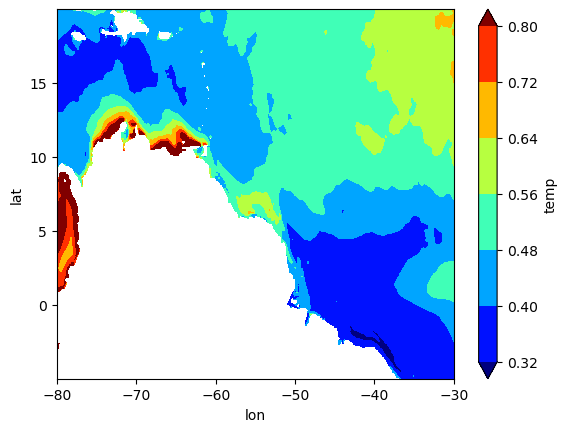

In [31]:
temp_anom_std.temp.sel(lat=slice(-5,20), lon=slice(-80,-30)).\
    plot.contourf(robust=True,cmap='jet')

In [32]:
april_std = temp_meso_anom.sel(time=temp_meso_anom.month == 4).groupby('year').std().compute()
april_std

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


<xarray.Dataset> Size: 111MB
Dimensions:  (year: 22, lat: 499, lon: 1260)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * year     (year) int64 176B 1993 1994 1995 1996 1997 ... 2011 2012 2013 2014
Data variables:
    temp     (year, lat, lon) float64 111MB 0.1452 0.1571 0.1709 ... nan nan nan

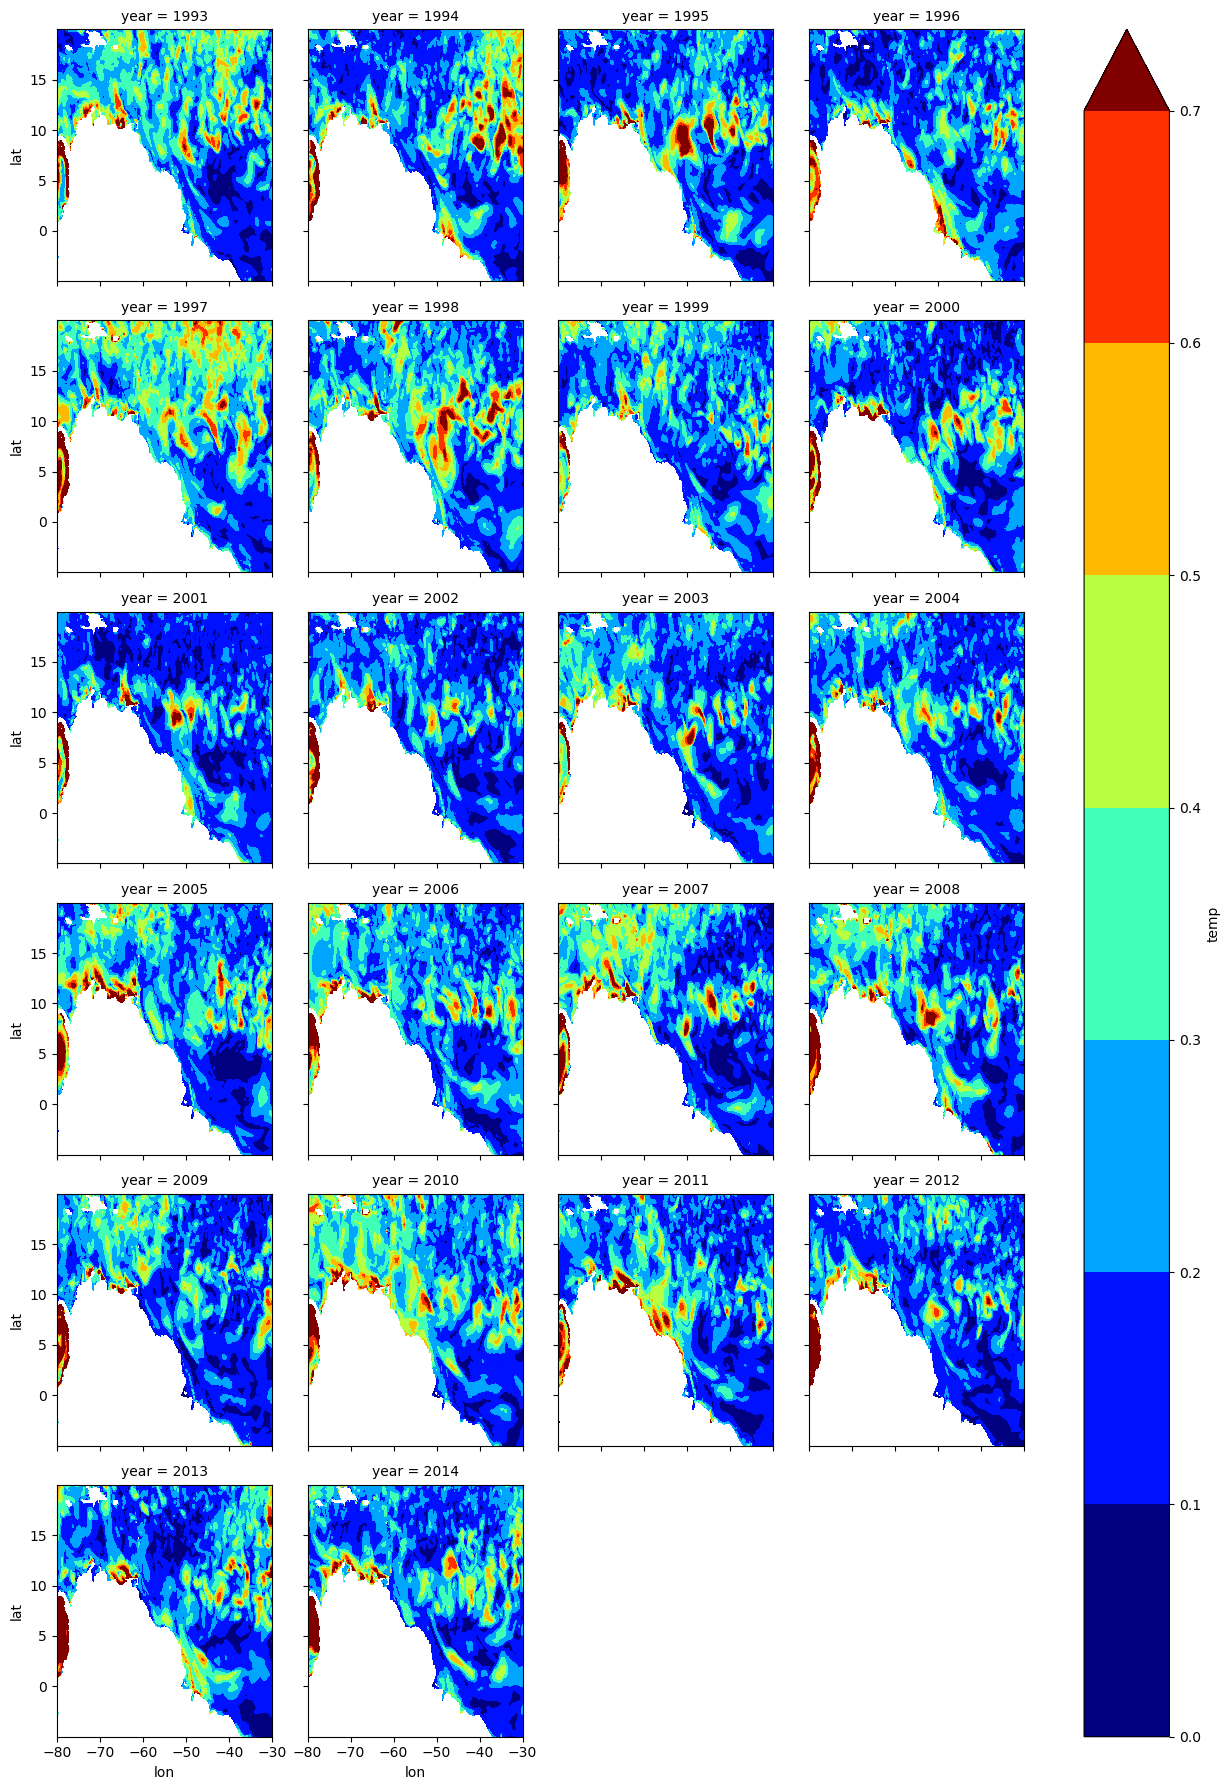

In [33]:
april_std.temp.sel(lat=slice(-5,20), lon=slice(-80,-30)).\
    plot.contourf(x='lon',y='lat',col='year',col_wrap=4,robust=True,cmap='jet')